# Projet d'examen — Machine Learning
## Sujet C : Estimation de la valeur d'un bien immobilier (California Housing)

**Problématique** : prédire la valeur d'un bien immobilier à partir de ses caractéristiques.

**Plan** : EDA → Prétraitement → Modélisation → Sélection d'hyperparamètres → Évaluation → Interprétabilité → Analyse critique

## 1. Chargement des données et analyse exploratoire (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Statistiques descriptives
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

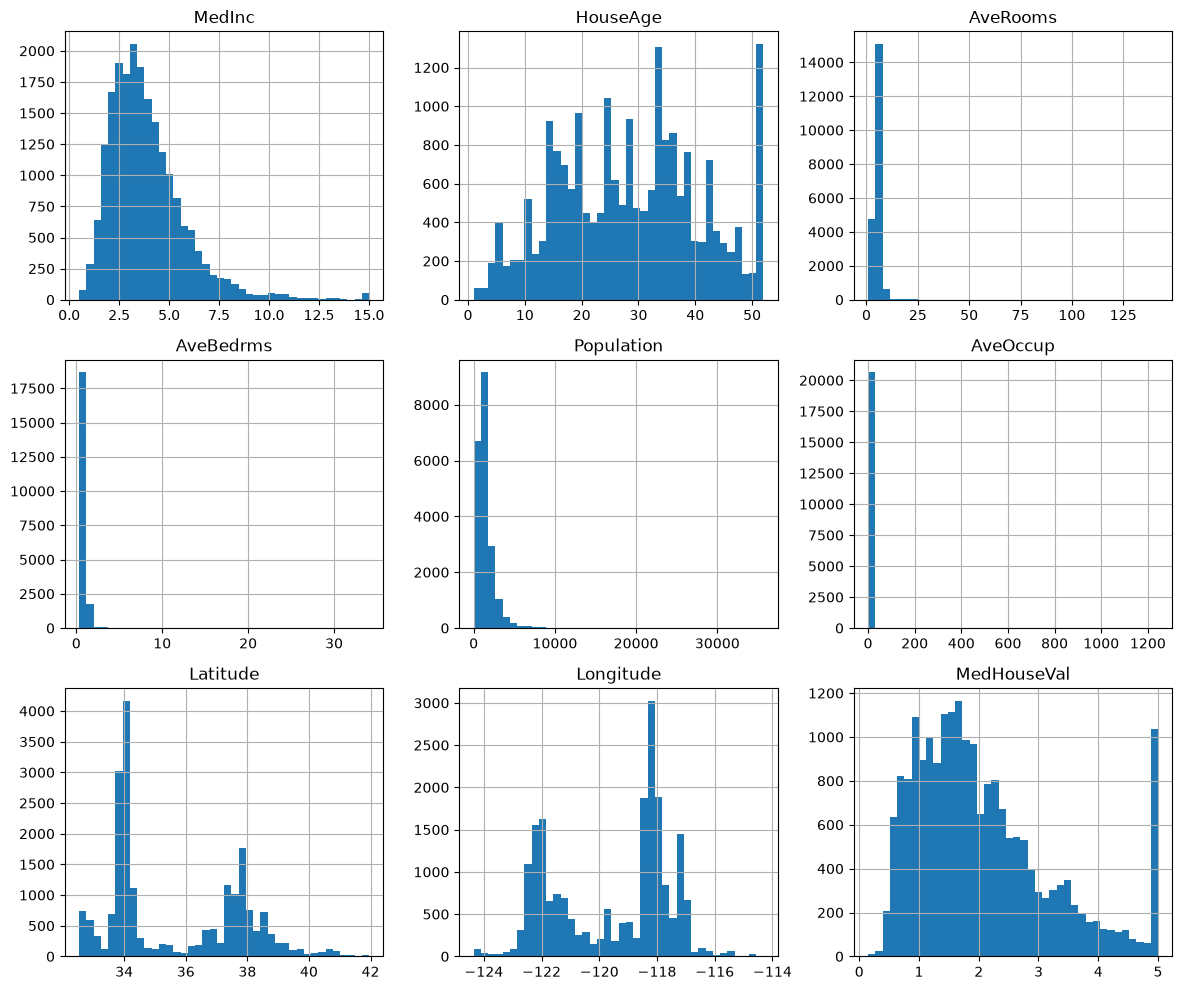

In [4]:
# Distributions des variables
df.hist(figsize=(12, 10), bins=40)
plt.tight_layout()
plt.show()

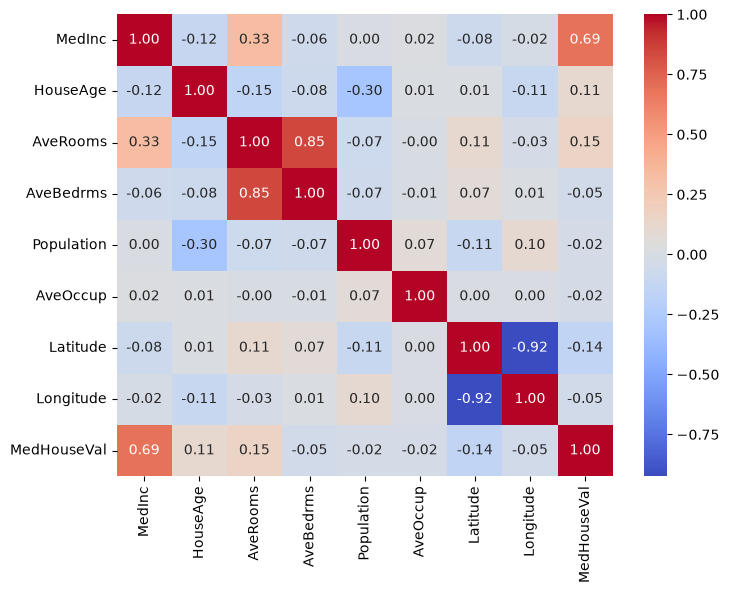

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [5]:
# Corrélations avec la variable cible (MedHouseVal)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

df.corr()["MedHouseVal"].sort_values(ascending=False)

**Observations EDA** (voir `PLAN.md` pour le detail complet) :
- `MedHouseVal` est exprimee en centaines de milliers de $ (doc officielle sklearn). Pic anormal a 5.0 -> plafonnement probable des prix eleves.
- `HouseAge` : pic a 52 -> plafonnement probable de l'age.
- `AveRooms`, `AveBedrms`, `Population`, `AveOccup` : distributions tres asymetriques avec des valeurs extremes (traitees en section 2).
- `MedInc` est la variable la plus correlee a la cible (0.69). `AveRooms`/`AveBedrms` tres colineaires (0.85), `Latitude`/`Longitude` aussi (-0.92).

## 2. Prétraitement

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Split AVANT tout apprentissage de transformation (evite le data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

### 2.1 Détection et traitement des valeurs aberrantes

La documentation officielle du dataset précise que les valeurs extrêmes de `AveRooms`/`AveBedrms`/`AveOccup` correspondent à de vrais quartiers avec peu de foyers et beaucoup de logements vides (ex. zones de vacances) — ce ne sont **pas des erreurs de saisie**. On choisit donc de **plafonner (capping/winsorization)** ces valeurs plutôt que de supprimer les lignes, afin de ne pas perdre d'observations réelles tout en limitant l'influence des valeurs extrêmes sur les modèles sensibles à l'échelle (Ridge, KNN).

Les bornes sont calculées **uniquement sur le train** (méthode IQR, k=1.5) puis appliquées identiquement au train et au test, pour éviter toute fuite de données.

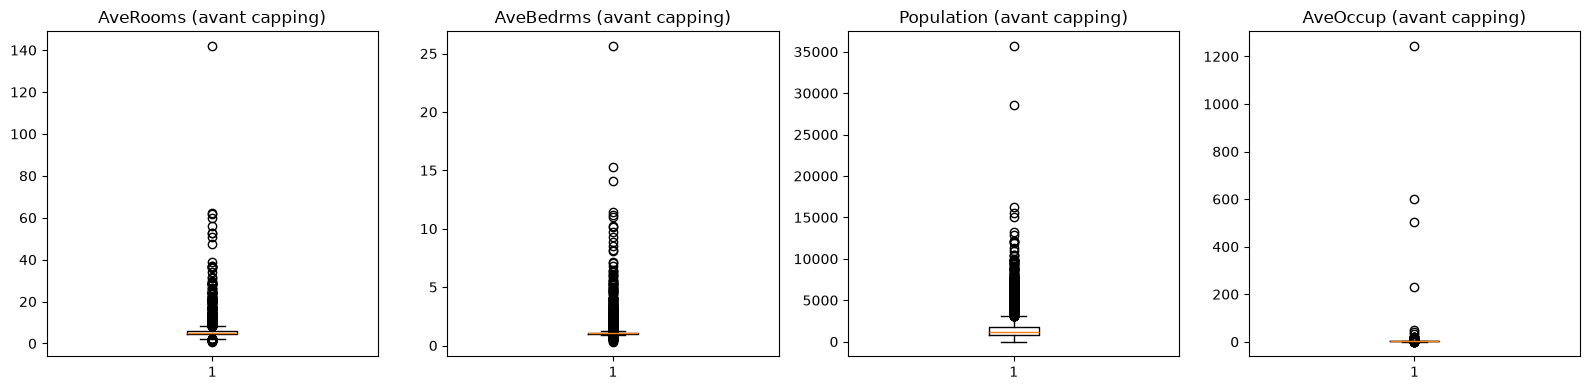

In [7]:
cols_to_cap = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_to_cap):
    ax.boxplot(X_train[col])
    ax.set_title(col + " (avant capping)")
plt.tight_layout()
plt.show()

In [8]:
bounds = {}
for col in cols_to_cap:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[col] = (lower, upper)
    n_out = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"{col}: bornes=[{lower:.2f}, {upper:.2f}] -> {n_out} valeurs plafonnees ({100*n_out/len(X_train):.2f}%)")

X_train_capped = X_train.copy()
X_test_capped = X_test.copy()
for col, (lower, upper) in bounds.items():
    X_train_capped[col] = X_train_capped[col].clip(lower, upper)
    X_test_capped[col] = X_test_capped[col].clip(lower, upper)

AveRooms: bornes=[2.04, 8.47] -> 410 valeurs plafonnees (2.48%)
AveBedrms: bornes=[0.87, 1.24] -> 1153 valeurs plafonnees (6.98%)
Population: bornes=[-616.50, 3131.50] -> 955 valeurs plafonnees (5.78%)
AveOccup: bornes=[1.15, 4.56] -> 582 valeurs plafonnees (3.52%)


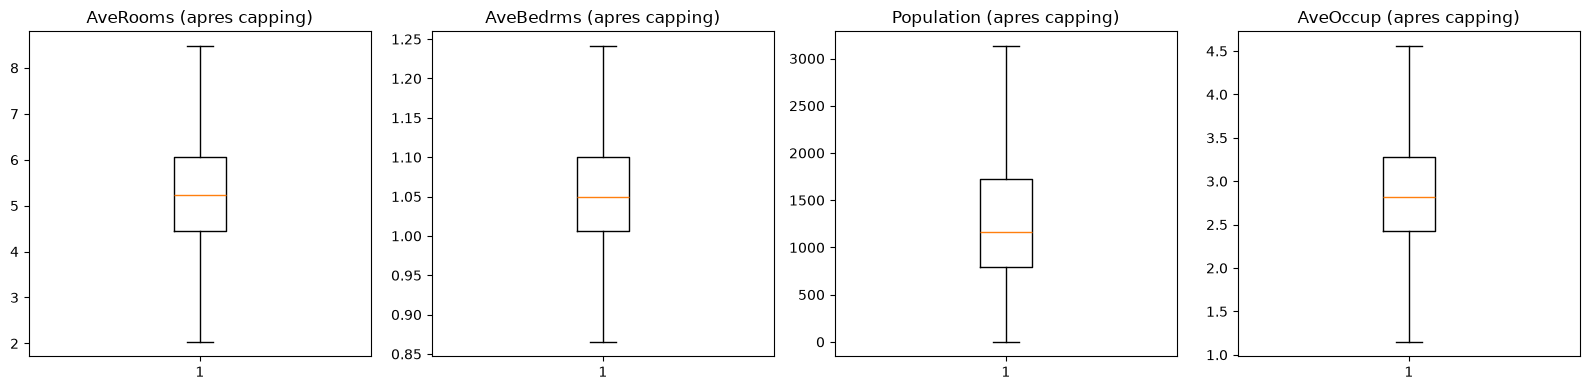

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_to_cap):
    ax.boxplot(X_train_capped[col])
    ax.set_title(col + " (apres capping)")
plt.tight_layout()
plt.show()

### 2.2 Standardisation

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

## 3. Modelisation — comparaison de 3 familles d'algorithmes

- **Ridge** : modele lineaire regularise (regularisation L2). Robuste face a la colinearite `AveRooms`/`AveBedrms` et `Latitude`/`Longitude` detectee en EDA. Hypothese forte : relation lineaire entre variables et cible.
- **RandomForest** : ensemble d'arbres. Capture les relations non lineaires et les interactions entre variables sans hypothese de linearite. Peu sensible aux valeurs extremes residuelles.
- **KNN** : modele de comparaison base sur la similarite locale. Sensible a la standardisation (deja appliquee) et a la dimensionnalite. Sert de point de comparaison supplementaire, pas necessairement le moins performant.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate, KFold

models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=1),
    "KNN": KNeighborsRegressor(),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

baseline_results = {}
for name, model in models.items():
    cv_res = cross_validate(model, X_train_scaled, y_train, cv=kf, scoring=scoring, n_jobs=1)
    baseline_results[name] = {
        "RMSE": -cv_res["test_RMSE"].mean(),
        "RMSE_std": cv_res["test_RMSE"].std(),
        "MAE": -cv_res["test_MAE"].mean(),
        "R2": cv_res["test_R2"].mean(),
    }

pd.DataFrame(baseline_results).T

,RMSE,RMSE_std,MAE,R2
Ridge,0.665091,0.015030,0.488127,0.668938
RandomForest,0.511666,0.011182,0.335461,0.804096
KNN,0.624005,0.007204,0.430228,0.708615


**Résultats baseline (validation croisée 5-fold sur le train, avant tuning)** :

| Modèle | RMSE | MAE | R² |
|---|---|---|---|
| Ridge | 0.665 | 0.488 | 0.669 |
| RandomForest | 0.512 | 0.336 | 0.804 |
| KNN | 0.624 | 0.430 | 0.709 |

RandomForest domine nettement (R²=0.80), cohérent avec sa capacité à capturer les relations non linéaires identifiées en EDA (notamment via Latitude/Longitude). KNN devance Ridge, contrairement à l'attente initiale — a analyser en section 7 (probablement lié aux relations géographiques locales mieux captées par la similarité de voisinage que par un modèle linéaire).

## 4. Selection de modele et recherche d'hyperparametres

Espace de recherche exploré, justifié par modèle :
- **Ridge** — `alpha` (force de régularisation) sur une échelle large [0.1, 100] : au-dessus de 100 le modèle sous-apprend trop, en dessous de 0.1 la régularisation devient négligeable face à Ridge par défaut (alpha=1.0). Recherche exhaustive (`GridSearchCV`), peu coûteuse.
- **RandomForest** — `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` : espace large et coûteux à explorer entraînement par entraînement, d'où `RandomizedSearchCV` (10 tirages) plutôt qu'une grille exhaustive, pour rester rapide.
- **KNN** — `n_neighbors` (3 à 15, au-delà le modèle lisse trop et perd en précision locale) et `weights` (uniforme vs pondéré par distance). Recherche exhaustive, peu coûteuse.

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# --- Ridge : grille exhaustive, peu couteuse ---
ridge_grid = {"alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(Ridge(), ridge_grid, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=1)
ridge_search.fit(X_train_scaled, y_train)

# --- RandomForest : RandomizedSearch (espace plus grand, cout par entrainement eleve) ---
rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_grid, n_iter=10, cv=kf, scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=1,
)
rf_search.fit(X_train_scaled, y_train)

# --- KNN : grille exhaustive, peu couteuse ---
knn_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15], "weights": ["uniform", "distance"]}
knn_search = GridSearchCV(KNeighborsRegressor(), knn_grid, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=1)
knn_search.fit(X_train_scaled, y_train)

tuned_results = {
    "Ridge": {"best_params": ridge_search.best_params_, "RMSE": -ridge_search.best_score_},
    "RandomForest": {"best_params": rf_search.best_params_, "RMSE": -rf_search.best_score_},
    "KNN": {"best_params": knn_search.best_params_, "RMSE": -knn_search.best_score_},
}
pd.DataFrame(tuned_results).T

,best_params,RMSE
Ridge,{'alpha': 0.1},0.665091
RandomForest,"{'n_estimators': 200, 'min_samples_leaf': 2, '...",0.500498
KNN,"{'n_neighbors': 15, 'weights': 'distance'}",0.60211


**Résultats après tuning** :

| Modèle | Meilleurs hyperparamètres | RMSE (CV) |
|---|---|---|
| Ridge | `alpha=0.1` | 0.665 (quasi inchangé) |
| **RandomForest** | `n_estimators=200, max_depth=None, min_samples_leaf=2, max_features='sqrt'` | **0.5005** (amélioré) |
| KNN | `n_neighbors=15, weights='distance'` | 0.602 (amélioré) |

RandomForest reste le meilleur modèle et est encore amélioré par le tuning → c'est le modèle retenu pour l'évaluation finale (section 5) et l'interprétabilité (section 6).

## 5. Evaluation finale

Evaluation finale (test) -> RMSE=0.4974  MAE=0.3301  R2=0.8112


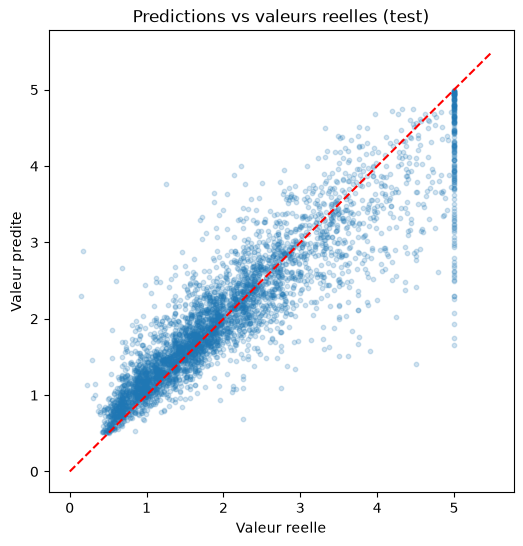

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2, max_features="sqrt",
    random_state=42, n_jobs=1,
)
best_rf.fit(X_train_scaled, y_train)
y_pred = best_rf.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Evaluation finale (test) -> RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
plt.plot([0, 5.5], [0, 5.5], "r--")
plt.xlabel("Valeur reelle")
plt.ylabel("Valeur predite")
plt.title("Predictions vs valeurs reelles (test)")
plt.show()

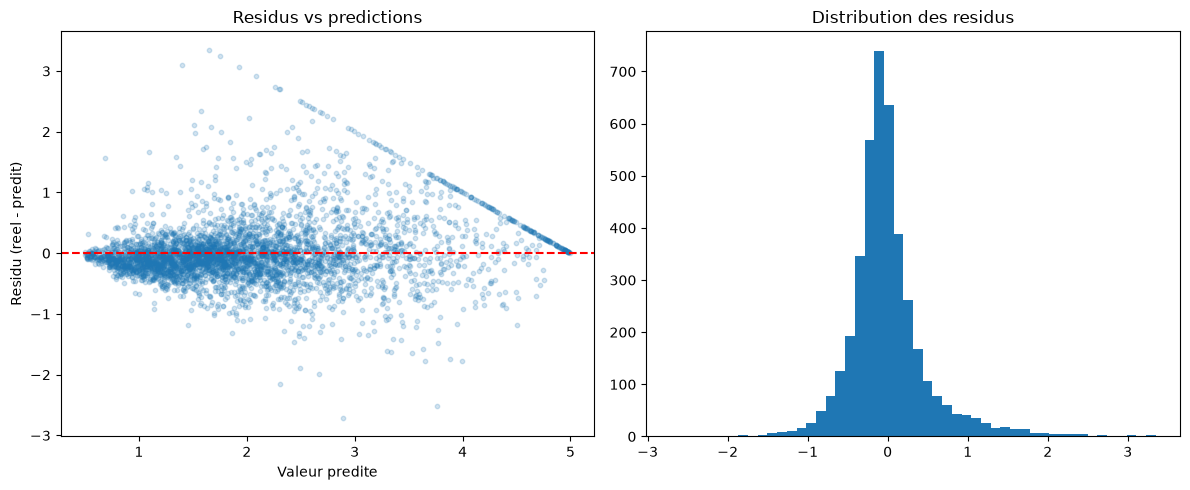

Residu moyen: -0.0023907754466355414
Residu std: 0.4974695746387627

Sur les 190 observations plafonnees (y_test>=4.9): RMSE local=1.1419 vs RMSE global=0.4974


In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=10)
axes[0].axhline(0, color="r", linestyle="--")
axes[0].set_xlabel("Valeur predite")
axes[0].set_ylabel("Residu (reel - predit)")
axes[0].set_title("Residus vs predictions")
axes[1].hist(residuals, bins=50)
axes[1].set_title("Distribution des residus")
plt.tight_layout()
plt.show()

print("Residu moyen:", residuals.mean())
print("Residu std:", residuals.std())

# Segment ou le modele se trompe le plus : observations proches du plafond de prix (5.0)
mask_capped = y_test >= 4.9
rmse_capped = mean_squared_error(y_test[mask_capped], y_pred[mask_capped]) ** 0.5
print(f"\nSur les {mask_capped.sum()} observations plafonnees (y_test>=4.9): RMSE local={rmse_capped:.4f} vs RMSE global={rmse:.4f}")

**Résultats évaluation finale (test, jamais vu avant)** : RMSE=0.497, MAE=0.330, R²=0.811 — cohérent avec la validation croisée, pas de signe de surapprentissage.

**Découverte clé** : le nuage "prédictions vs réel" montre une ligne verticale nette à `y=5.0` — le modèle prédit des valeurs variées mais la vraie valeur est bloquée au plafond. Le RMSE local sur ces observations plafonnées (190 sur 4128) est de **1.14**, soit **2.3x pire** que le RMSE global (0.497). Ceci confirme empiriquement l'hypothèse de plafonnement des prix formulée en EDA, et constitue une limite factuelle et chiffrée du modèle à discuter en section 7.

## 6. Interpretabilite

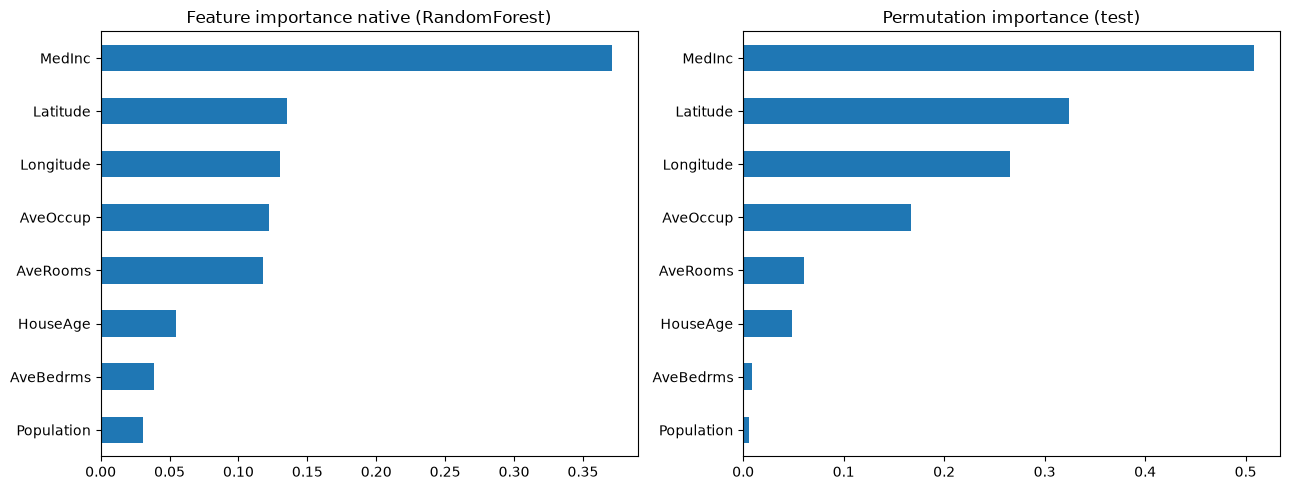

MedInc        0.371028
Latitude      0.135181
Longitude     0.130084
AveOccup      0.121953
AveRooms      0.117934
HouseAge      0.054815
AveBedrms     0.038601
Population    0.030404
dtype: float64


In [15]:
from sklearn.inspection import permutation_importance

feature_names = X.columns.tolist()

# Feature importance native (basee sur la reduction d'impurete)
native_imp = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Permutation importance (plus fiable : degradation du score quand la variable est melangee, calculee sur le test)
perm = permutation_importance(best_rf, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
native_imp.sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Feature importance native (RandomForest)")
perm_imp.sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Permutation importance (test)")
plt.tight_layout()
plt.show()

print(native_imp)

**Interprétation (mise en relation avec la problématique métier)** :

Classement cohérent entre les deux méthodes : `MedInc` (revenu médian du quartier) domine très largement (0.37 en importance native, 0.51 en permutation), suivi de `Latitude`/`Longitude`, puis `AveOccup` et `AveRooms`. `Population` et `AveBedrms` ont un poids quasi nul.

- Le revenu du quartier reste, sans surprise, le facteur le plus déterminant du prix d'un logement — cohérent avec la corrélation de 0.69 observée en EDA.
- `Latitude`/`Longitude` pèsent lourd dans RandomForest alors qu'elles étaient peu corrélées *linéairement* à la cible (-0.14/-0.05 en EDA) : ceci confirme que l'effet de la localisation est **non linéaire** (proximité de zones urbaines/côtières recherchées), ce qui explique pourquoi RandomForest et KNN dépassent Ridge sur ce dataset — un modèle linéaire ne peut pas capter cette structure géographique.
- Pour une utilisation métier (estimation automatisée), ce classement indique que les variables les plus fiables à collecter en priorité sont le revenu du quartier et la localisation précise du bien.

## 7. Analyse critique et discussion

*(Brouillon — à relire, personnaliser et compléter avant la remise. Toutes les valeurs citées viennent des résultats obtenus dans ce notebook.)*

### 7.1 Limites du modèle retenu et cas d'erreurs typiques

Le modèle final (RandomForest tuné) obtient de bonnes performances globales (RMSE=0.497, soit ~50 000 $ d'erreur type ; MAE=0.330, soit ~33 000 $ d'erreur moyenne ; R²=0.811) mais présente des limites concrètes et mesurables :

- **Erreurs fortes sur les biens de haute valeur** : sur les logements dont le prix réel est plafonné à 500 000 $ (190 observations du test), le RMSE local atteint 1.14, soit 2,3 fois pire que le RMSE global. Le modèle ne peut pas apprendre à distinguer un bien à 600 000 $ d'un bien à 2 000 000 $ car ces valeurs sont toutes écrasées à la même valeur cible dans les données d'entraînement — il s'agit d'une limite structurelle du dataset, pas d'un défaut du modèle lui-même.
- **Colinéarité entre variables** (`AveRooms`/`AveBedrms` à 0.85, `Latitude`/`Longitude` à -0.92) : RandomForest gère bien ce problème pour la prédiction, mais cela complique l'interprétation individuelle de l'importance de chaque variable (l'importance peut être partagée arbitrairement entre deux variables corrélées).
- **Précision individuelle limitée** : un R² de 0.81 signifie que le modèle explique bien la tendance générale, mais une MAE de ~33 000 $ reste trop imprécise pour une valorisation individuelle engageante (ex. usage notarial) — le modèle convient à une estimation indicative, pas à une décision automatisée sans supervision humaine.

### 7.2 Biais potentiels du jeu de données

- **Ancienneté des données** : le dataset provient du recensement américain de 1990 (35 ans). Le marché immobilier californien a radicalement changé depuis (essor de la Silicon Valley, crise de 2008, période Covid). Un modèle entraîné sur ces données ne serait pas directement utilisable pour une estimation de prix actuelle sans réentraînement sur des données récentes.
- **Censure des prix élevés** : les prix sont plafonnés à 500 001 $ dans les données source, ce qui biaise structurellement le modèle contre les biens de luxe (cf. 7.1).
- **Représentativité géographique restreinte** : le dataset ne couvre que la Californie, avec une forte concentration autour de Los Angeles et de la baie de San Francisco. Le modèle n'est pas généralisable à d'autres marchés immobiliers (autres États américains, ou hors des États-Unis).
- **Granularité par quartier ('block group', 600 à 3 000 habitants)** et non par bien individuel : les variables sont des moyennes/médianes de quartier, pas les caractéristiques précises d'un logement donné. Cela explique en partie le poids quasi nul de `Population` et `AveBedrms` dans le modèle — ces agrégats de quartier apportent peu d'information discriminante par rapport au revenu et à la localisation.

### 7.3 Pistes d'amélioration concrètes

- Réentraîner le modèle sur des données immobilières récentes (ex. données notariales, plateformes d'annonces immobilières) pour un usage en conditions réelles actuelles.
- Enrichir les données avec des variables au niveau du bien individuel (surface exacte, état, proximité écoles/transports) plutôt que des agrégats de quartier, afin de réduire l'erreur résiduelle.
- Traiter explicitement le plafonnement des prix : exclure les observations plafonnées de l'entraînement (avec justification claire), ou utiliser une régression adaptée aux données censurées (ex. régression de Tobit).
- Comparer avec des modèles de gradient boosting (XGBoost, LightGBM), potentiellement plus performants que RandomForest sur ce type de données tabulaires.
- Ajouter une analyse SHAP pour une interprétabilité au niveau de chaque prédiction individuelle, utile en cas de contestation d'une estimation automatisée dans un contexte métier réel.